# Q3 Part 2 – Convergence Tests for K = 5

Devise appropriate tests of convergence:
1. Grid independence study (vary $N_x \times N_y$)
2. Domain-size sensitivity (vary $q, s, r$)
3. Convergence rate analysis

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from q3_solver import solve, compute_phi_x, surface_phi_x, GAMMA

# params
K = 5.0
TOL = 1e-6

 Grid independence

In [6]:
grids = [(81, 41), (121, 61), (161, 81)]
q, s, r = 4.0, 4.0, 4.0
results_grid = {}

for Nx, Ny in grids:
    tag = f"{Nx}x{Ny}"
    print(f"\n=== Grid {tag} ===")
    phi, info = solve(K, Nx=Nx, Ny=Ny, q=q, s=s, r=r,
                      tol=TOL, max_iter=80000, check_every=200,
                      elliptic_only=True, verbose=True)
    results_grid[tag] = (phi, info)


=== Grid 81x41 ===
  it      1  |res|=1.110e+01  |upd|=2.224e-02  t=0.0s
  it   2000  |res|=8.746e-03  |upd|=1.433e-05  t=3.7s
  it   4000  |res|=6.114e-04  |upd|=1.009e-06  t=7.2s
  it   6000  |res|=5.057e-05  |upd|=8.411e-08  t=10.8s
  it   8000  |res|=4.286e-06  |upd|=7.203e-09  t=14.4s
  Converged at it=9200, |res|=9.744e-07, time=16.55s

=== Grid 121x61 ===
  it      1  |res|=1.724e+01  |upd|=1.516e-02  t=0.0s
  it   2000  |res|=4.693e-02  |upd|=3.414e-05  t=8.1s
  it   4000  |res|=1.118e-02  |upd|=8.173e-06  t=16.3s
  it   6000  |res|=3.162e-03  |upd|=2.318e-06  t=24.5s
  it   8000  |res|=9.730e-04  |upd|=7.150e-07  t=32.5s
  it  10000  |res|=3.119e-04  |upd|=2.297e-07  t=40.6s
  it  12000  |res|=1.018e-04  |upd|=7.515e-08  t=48.7s
  it  14000  |res|=3.348e-05  |upd|=2.478e-08  t=56.9s
  it  16000  |res|=1.104e-05  |upd|=8.196e-09  t=64.9s
  it  18000  |res|=3.643e-06  |upd|=2.715e-09  t=73.1s
  it  20000  |res|=1.202e-06  |upd|=8.999e-10  t=81.3s
  Converged at it=20400, |res|=

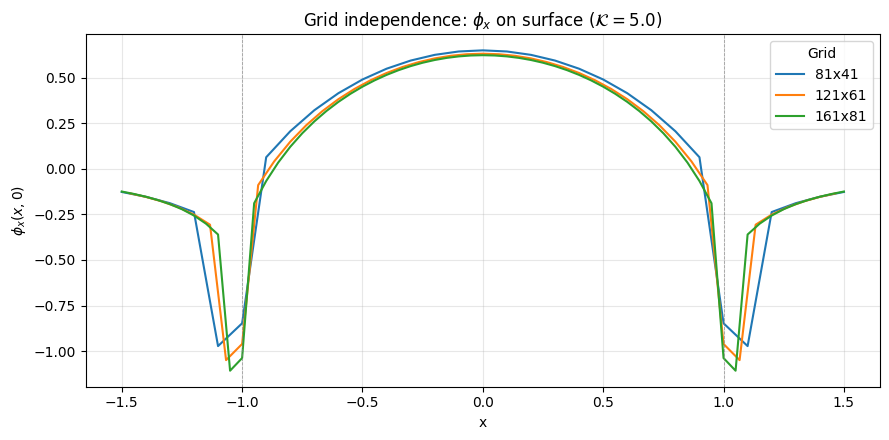

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for tag, (phi, info) in results_grid.items():
    x = info["x"]; dx = info["dx"]
    ux = surface_phi_x(phi, dx)
    mask = (x >= -1.5) & (x <= 1.5)
    ax.plot(x[mask], ux[mask], lw=1.5, label=tag)

ax.axvline(-1, color="grey", ls="--", lw=0.6, alpha=0.7)
ax.axvline( 1, color="grey", ls="--", lw=0.6, alpha=0.7)
ax.set_xlabel("x"); ax.set_ylabel(r"$\phi_x(x, 0)$")
ax.set_title(rf"Grid independence: $\phi_x$ on surface ($\mathcal{{K}}={K}$)")
ax.legend(title="Grid"); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q3_p2_grid_independence.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Quantitative convergence table
ref_tag = f"{grids[-1][0]}x{grids[-1][1]}"
phi_ref, info_ref = results_grid[ref_tag]
x_ref = info_ref["x"]; ux_ref = surface_phi_x(phi_ref, info_ref["dx"])
idx0_ref = np.argmin(np.abs(x_ref))
ux0_ref = ux_ref[idx0_ref]

print(f"{'Grid':<12s} {'iters':>8s} {'time(s)':>8s} {'phi_x(0,0)':>12s} {'rel err':>12s}")
print("-" * 56)
for tag, (phi, info) in results_grid.items():
    x = info["x"]; dx = info["dx"]
    ux = surface_phi_x(phi, dx)
    idx0 = np.argmin(np.abs(x))
    ux0 = ux[idx0]
    err = abs(ux0 - ux0_ref) / (abs(ux0_ref) + 1e-15)
    print(f"{tag:<12s} {info['iters']:8d} {info['seconds']:8.2f} {ux0:12.6f} {err:12.3e}")

Grid            iters  time(s)   phi_x(0,0)      rel err
--------------------------------------------------------
81x41            9200    16.55     0.650669    4.257e-02
121x61          20400    82.96     0.632264    1.308e-02
161x81          36000   259.65     0.624098    0.000e+00


 Domain size sensitivity

In [10]:
Nx, Ny = 161, 81
domain_configs = [(3.0,3.0,3.0), (4.0,4.0,4.0), (6.0,6.0,6.0), (8.0,8.0,8.0)]
results_dom = {}

for qi, si, ri in domain_configs:
    tag = f"q={qi},s={si},r={ri}"
    print(f"\n--- Domain [{-qi},{si}]x[0,{ri}] ---")
    phi, info = solve(K, Nx=Nx, Ny=Ny, q=qi, s=si, r=ri,
                      tol=TOL, max_iter=80000, check_every=200,
                      elliptic_only=True, verbose=True)
    results_dom[tag] = (phi, info)


--- Domain [-3.0,3.0]x[0,3.0] ---
  it      1  |res|=3.074e+01  |upd|=8.477e-03  t=0.0s
  it   2000  |res|=2.046e-01  |upd|=4.714e-05  t=14.6s
  it   4000  |res|=7.995e-02  |upd|=1.849e-05  t=29.0s
  it   6000  |res|=3.544e-02  |upd|=8.211e-06  t=43.5s
  it   8000  |res|=1.677e-02  |upd|=3.891e-06  t=57.9s
  it  10000  |res|=8.279e-03  |upd|=1.924e-06  t=72.4s
  it  12000  |res|=4.209e-03  |upd|=9.789e-07  t=86.9s
  it  14000  |res|=2.182e-03  |upd|=5.081e-07  t=101.2s
  it  16000  |res|=1.146e-03  |upd|=2.671e-07  t=115.6s
  it  18000  |res|=6.070e-04  |upd|=1.416e-07  t=130.2s
  it  20000  |res|=3.231e-04  |upd|=7.542e-08  t=144.9s
  it  22000  |res|=1.725e-04  |upd|=4.030e-08  t=159.8s
  it  24000  |res|=9.226e-05  |upd|=2.158e-08  t=174.1s
  it  26000  |res|=4.940e-05  |upd|=1.157e-08  t=188.6s
  it  28000  |res|=2.647e-05  |upd|=6.206e-09  t=203.0s
  it  30000  |res|=1.419e-05  |upd|=3.331e-09  t=217.5s
  it  32000  |res|=7.603e-06  |upd|=1.788e-09  t=231.9s
  it  34000  |res|=4.

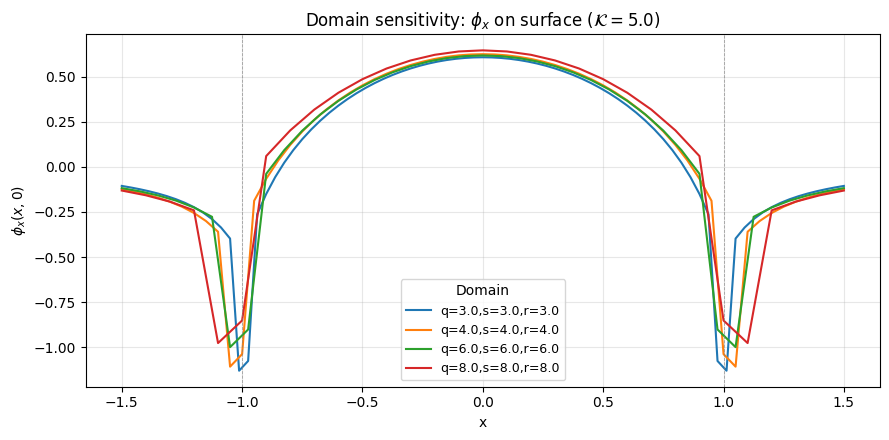

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for tag, (phi, info) in results_dom.items():
    x = info["x"]; dx = info["dx"]
    ux = surface_phi_x(phi, dx)
    mask = (x >= -1.5) & (x <= 1.5)
    ax.plot(x[mask], ux[mask], lw=1.5, label=tag)

ax.axvline(-1, color="grey", ls="--", lw=0.6, alpha=0.7)
ax.axvline( 1, color="grey", ls="--", lw=0.6, alpha=0.7)
ax.set_xlabel("x"); ax.set_ylabel(r"$\phi_x(x, 0)$")
ax.set_title(rf"Domain sensitivity: $\phi_x$ on surface ($\mathcal{{K}}={K}$)")
ax.legend(title="Domain", fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q3_p2_domain_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

Convergence rate analysis

Asymptotic convergence factor rho ~ 0.93899


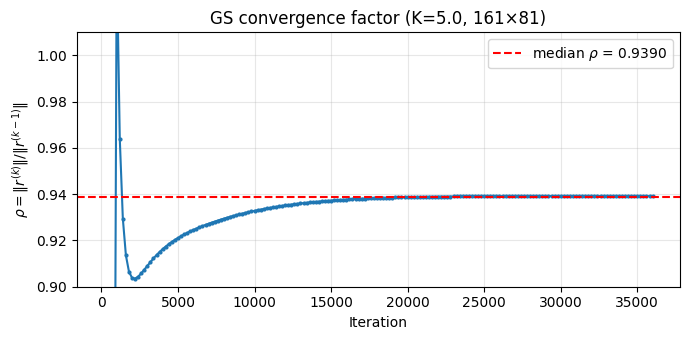

In [12]:
_, info_base = results_grid["161x81"]
hist = info_base["hist"]
res_arr = np.array([h["res"] for h in hist])
its_arr = np.array([h["it"]  for h in hist])

rho = res_arr[1:] / res_arr[:-1]
skip = max(5, len(rho) // 4)
rho_asymptotic = np.median(rho[skip:])
print(f"Asymptotic convergence factor rho ~ {rho_asymptotic:.5f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(its_arr[1:], rho, "o-", markersize=2)
ax.axhline(rho_asymptotic, color="r", ls="--",
           label=rf"median $\rho$ = {rho_asymptotic:.4f}")
ax.set_xlabel("Iteration"); ax.set_ylabel(r"$\rho = \|r^{(k)}\| / \|r^{(k-1)}\|$")
ax.set_title(f"GS convergence factor (K={K}, 161×81)")
ax.set_ylim(0.9, 1.01); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q3_p2_convergence_factor.png", dpi=150, bbox_inches="tight")
plt.show()